<a href="https://colab.research.google.com/github/Manishmaity/EV-Battery-Health-Predictor-using-Machine-Learning/blob/main/EV_Battery_Health_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV Battery Health Predictor using Machine Learning
**Module 1 Project — Google Colab Notebook**

This notebook trains a classification model to predict EV battery health
(**Healthy / Degrading / Critical**) using the real NASA Li-ion Battery
Dataset (`Battery_Data_Cleaned.csv`).

**How to run in Colab:**
1. Click the folder icon on the left sidebar.
2. Upload `Battery_Data_Cleaned.csv` (drag and drop, or use the upload button).
3. Runtime → Run all.


## 1. Setup

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})


## 2. Load the Dataset

If running in Colab, upload `Battery_Data_Cleaned.csv` first (see instructions above).


In [107]:
raw = pd.read_csv("/content/Battery_Data_Cleaned.csv")
print("Shape:", raw.shape)
raw.head()


Shape: (7368, 9)


,type,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,-1,4,47,0,1,00001.csv,0.983689,0.054543,0.183130
1,0,24,47,1,2,00002.csv,0.983689,0.054543,0.183130
2,1,4,47,2,3,00003.csv,0.983689,0.054543,0.183130
3,0,24,47,3,4,00004.csv,0.983689,0.051825,0.152493
4,-1,4,47,4,5,00005.csv,0.925990,0.051825,0.152493


## 3. Data Cleaning

- `Capacity == 0` marks a failed/invalid capacity reading in this dataset (a real
  cell never jumps straight to zero capacity), so those rows are dropped.
- Exact duplicate rows are dropped.
- The `filename` column (raw per-test file reference) isn't needed for analysis.


In [108]:
print("Missing values:\n", raw.isna().sum())
print("Exact duplicate rows:", raw.duplicated().sum())

df = raw.drop_duplicates().copy()
df = df[df["Capacity"] > 0]
df = df.drop(columns=["filename"])

df.to_csv("cleaned_battery_data.csv", index=False)
print("Cleaned shape:", df.shape)
df.describe()


Missing values:
 type                   0
ambient_temperature    0
battery_id             0
test_id                0
uid                    0
filename               0
Capacity               0
Re                     0
Rct                    0
dtype: int64
Exact duplicate rows: 0
Cleaned shape: (7318, 8)


,type,ambient_temperature,battery_id,test_id,uid,Capacity,Re,Rct
count,7318.000000,7318.000000,7318.000000,7318.000000,7318.000000,7318.000000,7318.000000,7318.000000
mean,0.002733,19.966931,32.113419,166.711943,3751.601530,0.830563,0.077760,0.124736
std,0.865409,11.200998,16.654821,140.071668,2183.632192,0.241635,0.022645,0.044641
min,-1.000000,4.000000,5.000000,0.000000,1.000000,0.032040,0.026691,0.038781
25%,-1.000000,4.000000,18.000000,54.000000,1870.250000,0.779678,0.060857,0.084519
50%,0.000000,24.000000,34.000000,124.000000,3703.500000,0.895389,0.074693,0.118338
75%,1.000000,24.000000,44.000000,245.000000,5613.750000,0.986963,0.095848,0.158353
max,1.000000,44.000000,56.000000,555.000000,7565.000000,1.292025,0.142128,0.238124


## 4. Build the Modeling Table

The dataset mixes three test types per battery cycle: `type = 1` (charge),
`type = 0` (discharge), `type = -1` (electrochemical impedance spectroscopy,
EIS). The EIS rows carry the genuine `Re` (electrolyte resistance) and `Rct`
(charge-transfer resistance) measurements, which are the electrical signatures
of aging. We use these rows as our modeling records.

**Health label:** each battery's own maximum observed `Capacity` is treated as
its rated (fresh-cell) capacity. State of Health is then:

`SOH % = Capacity / rated_capacity * 100`

with thresholds:
- **Healthy:** SOH ≥ 85%
- **Degrading:** 65% ≤ SOH < 85%
- **Critical:** SOH < 65%


In [109]:
imp = df[df["type"] == -1].copy()
imp = imp.drop_duplicates(subset=["battery_id", "Re", "Rct", "Capacity", "ambient_temperature"])

rated = imp.groupby("battery_id")["Capacity"].transform("max")
imp["SOH_percent"] = (imp["Capacity"] / rated) * 100

def label_health(soh):
    if soh >= 85:
        return "Healthy"
    elif soh >= 65:
        return "Degrading"
    else:
        return "Critical"

imp["health_status"] = imp["SOH_percent"].apply(label_health)
imp = imp.sort_values(["battery_id", "test_id"]).reset_index(drop=True)

print("Modeling table shape:", imp.shape)
imp["health_status"].value_counts()


Modeling table shape: (2705, 10)


,count
health_status,
Healthy,1470
Degrading,964
Critical,271


## 5. Exploratory Data Analysis

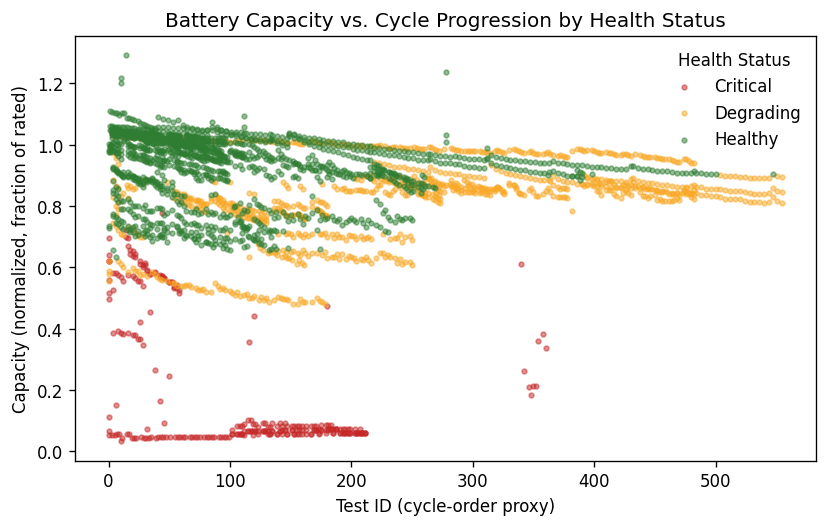

In [110]:
colors = {"Healthy": "#2E7D32", "Degrading": "#F9A825", "Critical": "#C62828"}

fig, ax = plt.subplots(figsize=(7, 4.5))
for status, sub in imp.groupby("health_status"):
    ax.scatter(sub["test_id"], sub["Capacity"], s=8, alpha=0.5, label=status, color=colors[status])
ax.set_xlabel("Test ID (cycle-order proxy)")
ax.set_ylabel("Capacity (normalized, fraction of rated)")
ax.set_title("Battery Capacity vs. Cycle Progression by Health Status")
ax.legend(title="Health Status", frameon=False)
plt.tight_layout()
plt.show()


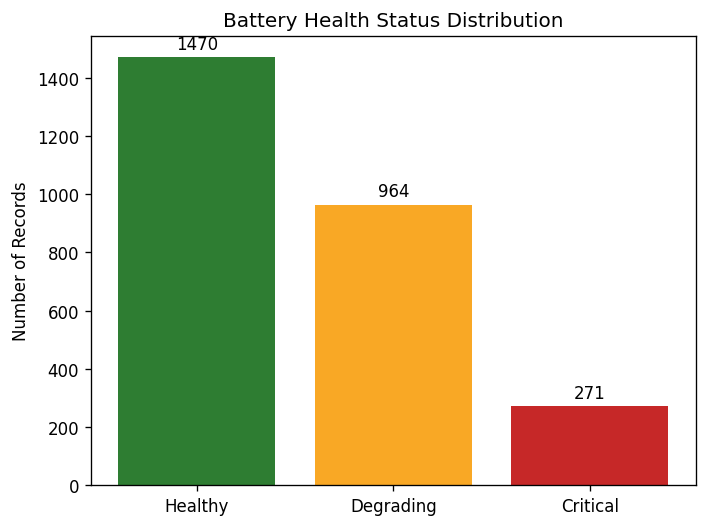

In [111]:
order = ["Healthy", "Degrading", "Critical"]
counts = imp["health_status"].value_counts()
vals = [counts.get(k, 0) for k in order]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(order, vals, color=[colors[k] for k in order])
ax.set_ylabel("Number of Records")
ax.set_title("Battery Health Status Distribution")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + max(vals)*0.01, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()


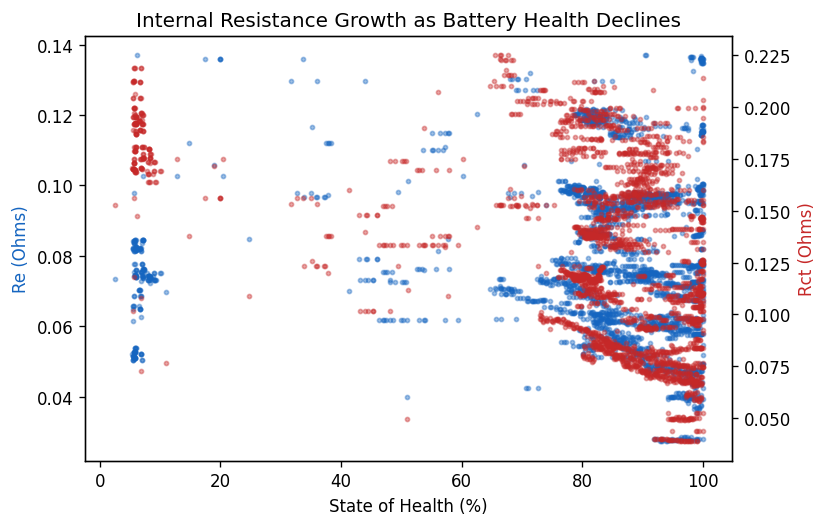

In [112]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax2 = ax.twinx()
ax.scatter(imp["SOH_percent"], imp["Re"], s=6, alpha=0.4, color="#1565C0", label="Re")
ax2.scatter(imp["SOH_percent"], imp["Rct"], s=6, alpha=0.4, color="#C62828", label="Rct")
ax.set_xlabel("State of Health (%)")
ax.set_ylabel("Re (Ohms)", color="#1565C0")
ax2.set_ylabel("Rct (Ohms)", color="#C62828")
ax.set_title("Internal Resistance Growth as Battery Health Declines")
plt.tight_layout()
plt.show()


## 6. Feature Selection

Features used: **Re, Rct, ambient_temperature, test_id**.

`Capacity` and `SOH_percent` are deliberately **excluded** from the model
inputs — they were used to *derive* the label, so including them would be
data leakage. The point of the model is to infer health from cheap impedance
and temperature signals, without needing a full capacity test.


In [113]:
feature_cols = ["Re", "Rct", "ambient_temperature", "test_id"]
X = imp[feature_cols]
y = imp["health_status"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (2028, 4)  Test size: (677, 4)


## 7. Train the Model

In [114]:
model = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=2,
    random_state=42, class_weight="balanced"
)
model.fit(X_train, y_train)
print("Model trained.")


Model trained.


## 8. Evaluate: Accuracy, Classification Report, Confusion Matrix

In [115]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1_macro:.4f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.9084
Macro F1: 0.8890

              precision    recall  f1-score   support

    Critical       0.78      0.90      0.84        68
   Degrading       0.87      0.95      0.91       241
     Healthy       0.97      0.89      0.92       368

    accuracy                           0.91       677
   macro avg       0.87      0.91      0.89       677
weighted avg       0.91      0.91      0.91       677



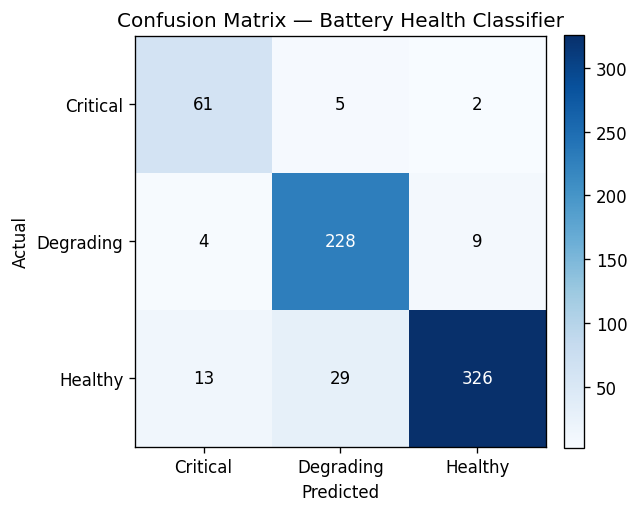

In [116]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.2, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(le.classes_))); ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_); ax.set_yticklabels(le.classes_)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Battery Health Classifier")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


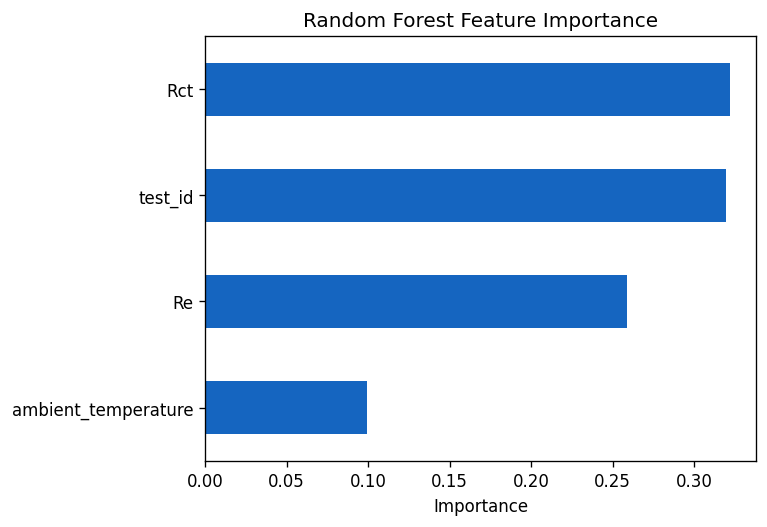

In [117]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
importances.plot(kind="barh", ax=ax, color="#1565C0")
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


## 9. Conclusion

The Random Forest classifier predicts battery health status (Healthy /
Degrading / Critical) from routine impedance and temperature measurements,
without needing a dedicated capacity test. See the accompanying project
report for full discussion of results, limitations, and next steps.
